[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sensioai/blog/blob/master/032_optimization/optimization.ipynb)

# Optimización. LABORATORIO 6.

ESTUDIANTE: VALDA PLAZA CAMILA MONSERRAT.
LABORATORIO: #6.
CARRERA: INGENIERIA DE SISTEMAS.

ESTE DATASET NOS HABLA DE 15 TIPOS DE VEGETABLES, SON IMAGENES REALES TOMADAS EN UNA GRANJA Y RECOLETADAS.

LO QUE SE HIZO PRIMERA MENTE FUE EN COLAB LA PRACTICA DONDE SE ESTA DESCARGANDO DESDE KAGGLE SIN NECESIDAD DE LLAMAR A UNA RUTA, ESTA VERSION ES VERSION CPU PARA TRAJETA INTEGRADA DESDE MANERA LOCAL RESUELTO.

SE HIZO VARIAS PRUEBAS PARA MEJORAR LA PRECISION DONDE EN UN PRINCIPIO SE UTILIZÓ DATA AUMENTATION, CON COMPOSE PERO LA PRECISION LLEGABA A UN 65% TANTO EN EL ENTREAMIENTO COMO EN EL PRECSION, DANDO CERCANIA EN SU RESULTADO, ESO INDICABA BUENA GENERALIZACION, PERO DECIDI COMENTARLO DADO QUE SIN ELLO SE HA LLEGADO CON ADAM (EN AMBOS CASOS SE TOMA EN CUENTA ADAM EL OPTIMIZADOR) A UN 80% MUY CERCANO AL ENTRENAMIENTO Y PRECISION RESULTANDO ASI UNA MEJOR GENERALIZACION.

In [ ]:
#import kagglehub

#path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

#print("Path to dataset files:", path)

In [ ]:
# Usa r"" para evitar que \ se interpreten como secuencias especiales
path = r"D:\monse estudio\anaconda\envs\inteligencia_artificial\cuadernillos\IA\IA - LABORATORIOS -20250916T060940Z-1-001\IA - LABORATORIOS\LABORATORIO (6)\Vegetable Images"

dataset_dir = path

In [ ]:
import os

dataset_dir = path
print("Contenido de dataset_dir:", os.listdir(dataset_dir))
for root, dirs, files in os.walk(dataset_dir):
    print(root, dirs)
    break

Contenido de dataset_dir: ['test', 'train', 'validation']
D:\monse estudio\anaconda\envs\inteligencia_artificial\cuadernillos\IA\IA - LABORATORIOS -20250916T060940Z-1-001\IA - LABORATORIOS\LABORATORIO (6)\Vegetable Images ['test', 'train', 'validation']


In [ ]:
import os

dataset_dir = path

train_dir = os.path.join(dataset_dir, 'train')
test_dir  = os.path.join(dataset_dir, 'test')

num_train = sum([len(files) for r, d, files in os.walk(train_dir)])
num_test  = sum([len(files) for r, d, files in os.walk(test_dir)])

print("Número de imágenes en train:", num_train)
print("Número de imágenes en test:", num_test)

classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
num_classes = len(classes)

print("Clases:", classes)
print("Número de clases:", num_classes)


Número de imágenes en train: 15000
Número de imágenes en test: 3000
Clases: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Número de clases: 15


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets

transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    #transforms.RandomHorizontalFlip(p=0.5),
    #transforms.RandomRotation(15),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    #transforms.ToTensor(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

trainset = datasets.ImageFolder(root=train_dir, transform=transform_train)
testset  = datasets.ImageFolder(root=test_dir, transform=transform_test)

print("Trainset:", len(trainset), "Testset:", len(testset))
print("Clases:", trainset.classes)
print("Número de clases:", len(trainset.classes))

Trainset: 15000 Testset: 3000
Clases: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Número de clases: 15


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
import numpy as np

train_images = np.array([np.array(img) for img, label in trainset])
X_test = np.array([np.array(img) for img, label in testset])

train_labels = np.array([label for img, label in trainset])
y_test = np.array([label for img, label in testset])
perm = np.random.permutation(len(train_images))
train_images = train_images[perm]
train_labels = train_labels[perm]

X_train, X_val, X_subset = train_images[:13500], train_images[13500:], train_images[:10000]
y_train, y_val, y_subset = train_labels[:13500], train_labels[13500:], train_labels[:10000]

X_train.shape, X_val.shape, X_test.shape, X_subset.shape

((13500, 3, 64, 64), (1500, 3, 64, 64), (3000, 3, 64, 64), (10000, 3, 64, 64))

In [ ]:
import torch
import numpy as np


class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        X_flat = X.reshape(len(X), -1)
        self.X = torch.from_numpy((X_flat / 255.).astype(np.float32)).float()
        self.Y = torch.from_numpy(Y).long().to(device)
    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

dataset = {
    'train': Dataset(X_subset, y_subset),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(10000, 1500)

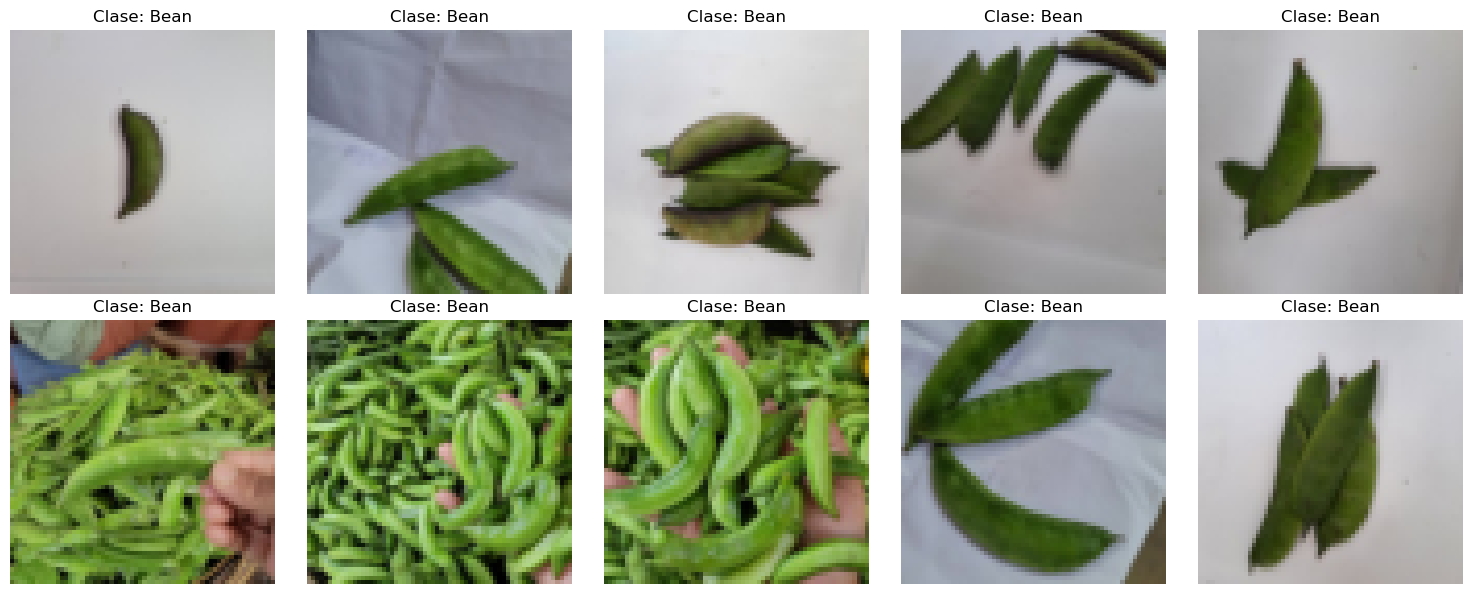

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(image_tensor):
    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]
    image = image_tensor.clone()

    for i in range(3):
        image[i] = (image[i] * std[i]) + mean[i]
    image = image.numpy().transpose((1, 2, 0))
    image = np.clip(image, 0, 1)

    return image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    image, label = trainset[i]
    denormalized_image = denormalize(image)
    axes[i].imshow(denormalized_image)
    axes[i].set_title(f'Clase: {trainset.classes[label]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

#def build_model(D_in=80*80*3, H=150, D_out=15):
    #return torch.nn.Sequential(
        #torch.nn.Linear(D_in, H),
        #torch.nn.ReLU(),
        #torch.nn.Linear(H, H),
        #torch.nn.ReLU(),
        #torch.nn.Linear(H, D_out)
   # ).cuda()
def build_model(D_in=64*64*3, H=150, D_out=15):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p=0.5),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Dropout(p=0.5),
        torch.nn.Linear(H, D_out)
    ).to(device)

def fit(model, dataloader, optimizer, epochs=120, log_each=10, weight_decay=0, early_stopping=40):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}

## Optimizadores

### Comparativa

Vamos a comparar los diferentes optimizadores presentados.

In [ ]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
hist_sgd = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.07250 en epoch 1
Epoch 10/120 loss 2.70873 acc 0.06500 val_loss 2.71012 val_acc 0.07250
Epoch 20/120 loss 2.70783 acc 0.06979 val_loss 2.71021 val_acc 0.07250
Epoch 30/120 loss 2.70792 acc 0.06999 val_loss 2.71037 val_acc 0.04700
Epoch 40/120 loss 2.70794 acc 0.06729 val_loss 2.71055 val_acc 0.04700
Entrenamiento detenido en epoch 41 por no mejorar en 40 epochs seguidas


C:\Users\hp\AppData\Local\Temp\ipykernel_24164\3493992184.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


In [ ]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.04700 en epoch 1
Mejor modelo guardado con acc 0.05800 en epoch 3
Mejor modelo guardado con acc 0.06400 en epoch 5
Mejor modelo guardado con acc 0.09950 en epoch 8
Mejor modelo guardado con acc 0.11150 en epoch 9
Epoch 10/120 loss 2.67457 acc 0.11322 val_loss 2.65839 val_acc 0.08650
Mejor modelo guardado con acc 0.12050 en epoch 12
Mejor modelo guardado con acc 0.14650 en epoch 15
Mejor modelo guardado con acc 0.21600 en epoch 17
Mejor modelo guardado con acc 0.26300 en epoch 19
Epoch 20/120 loss 2.23326 acc 0.23013 val_loss 2.19045 val_acc 0.23000
Mejor modelo guardado con acc 0.29100 en epoch 21
Mejor modelo guardado con acc 0.30700 en epoch 22
Mejor modelo guardado con acc 0.31200 en epoch 23
Mejor modelo guardado con acc 0.32950 en epoch 24
Mejor modelo guardado con acc 0.33400 en epoch 25
Mejor modelo guardado con acc 0.33800 en epoch 26
Mejor modelo guardado con acc 0.34450 en epoch 27
Mejor modelo guardado con acc 0.34900 en epoch 28
Mejor modelo 

C:\Users\hp\AppData\Local\Temp\ipykernel_24164\3493992184.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


In [ ]:
model = build_model()
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.42600 en epoch 1
Mejor modelo guardado con acc 0.47250 en epoch 2
Mejor modelo guardado con acc 0.54400 en epoch 3
Mejor modelo guardado con acc 0.57750 en epoch 4
Mejor modelo guardado con acc 0.60650 en epoch 5
Mejor modelo guardado con acc 0.62950 en epoch 6
Mejor modelo guardado con acc 0.65550 en epoch 7
Mejor modelo guardado con acc 0.67700 en epoch 8
Mejor modelo guardado con acc 0.68050 en epoch 9
Mejor modelo guardado con acc 0.70450 en epoch 10
Epoch 10/120 loss 1.01388 acc 0.67402 val_loss 0.96279 val_acc 0.70450
Mejor modelo guardado con acc 0.70600 en epoch 11
Mejor modelo guardado con acc 0.72550 en epoch 12
Mejor modelo guardado con acc 0.74250 en epoch 13
Mejor modelo guardado con acc 0.74950 en epoch 16
Mejor modelo guardado con acc 0.75500 en epoch 18
Mejor modelo guardado con acc 0.76500 en epoch 19
Mejor modelo guardado con acc 0.76700 en epoch 20
Epoch 20/120 loss 0.69779 acc 0.77306 val_loss 0.77399 val_acc 0.76700
Mejor modelo guar

C:\Users\hp\AppData\Local\Temp\ipykernel_24164\3493992184.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


In [ ]:
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.38950 en epoch 1
Mejor modelo guardado con acc 0.47150 en epoch 2
Mejor modelo guardado con acc 0.50300 en epoch 3
Mejor modelo guardado con acc 0.52650 en epoch 4
Mejor modelo guardado con acc 0.58300 en epoch 5
Mejor modelo guardado con acc 0.60550 en epoch 7
Mejor modelo guardado con acc 0.62750 en epoch 8
Mejor modelo guardado con acc 0.63650 en epoch 9
Mejor modelo guardado con acc 0.66450 en epoch 10
Epoch 10/120 loss 1.16282 acc 0.62600 val_loss 1.09598 val_acc 0.66450
Mejor modelo guardado con acc 0.67550 en epoch 12
Mejor modelo guardado con acc 0.69350 en epoch 13
Mejor modelo guardado con acc 0.70050 en epoch 15
Mejor modelo guardado con acc 0.71550 en epoch 16
Mejor modelo guardado con acc 0.73600 en epoch 17
Epoch 20/120 loss 0.87707 acc 0.72544 val_loss 0.84996 val_acc 0.73350
Mejor modelo guardado con acc 0.74000 en epoch 21
Mejor modelo guardado con acc 0.75750 en epoch 22
Mejor modelo guardado con acc 0.76300 en epoch 23
Mejor modelo gua

C:\Users\hp\AppData\Local\Temp\ipykernel_24164\3493992184.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


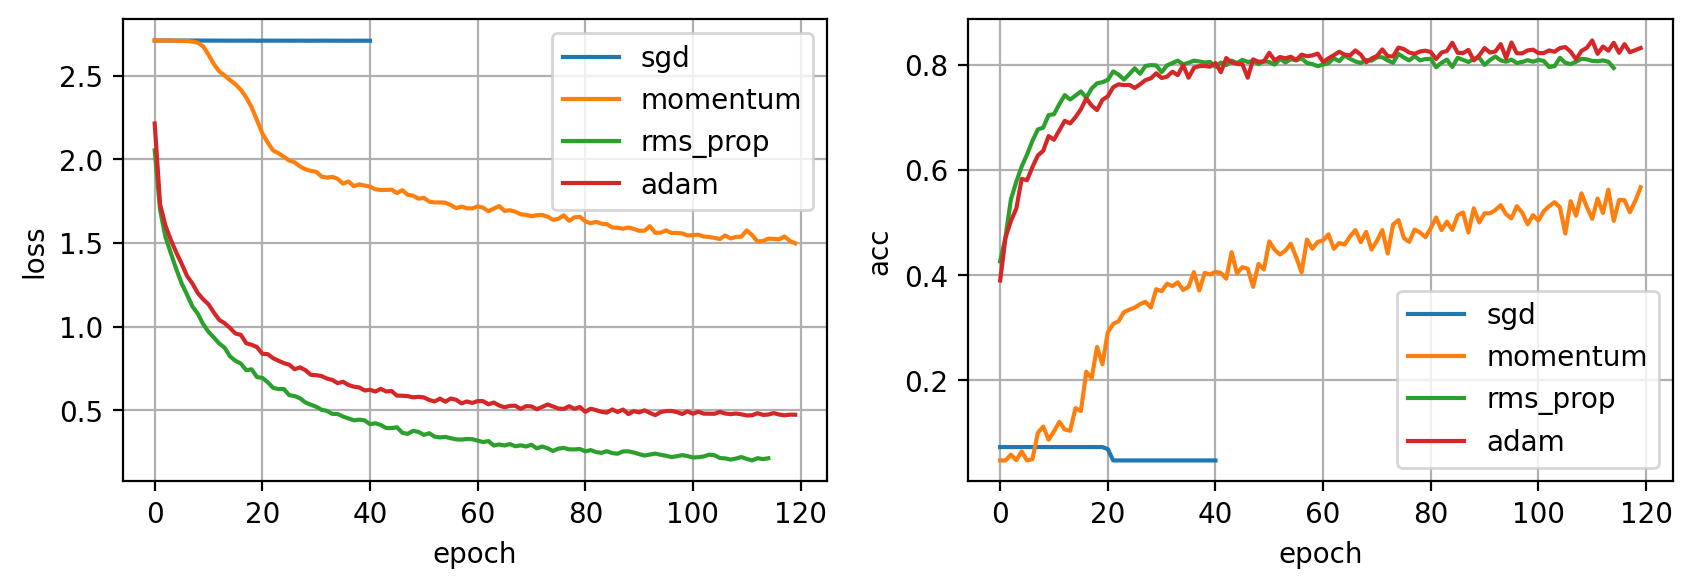

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="sgd")
ax.plot(hist_momentum['loss'], label="momentum")
ax.plot(hist_rms['loss'], label="rms_prop")
ax.plot(hist_adam['loss'], label="adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="sgd")
ax.plot(hist_momentum['val_acc'], label="momentum")
ax.plot(hist_rms['val_acc'], label="rms_prop")
ax.plot(hist_adam['val_acc'], label="adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..0.6392157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.84313726].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.81960785].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..0.9843137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7490196].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.8352941].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8352941].
Clippin

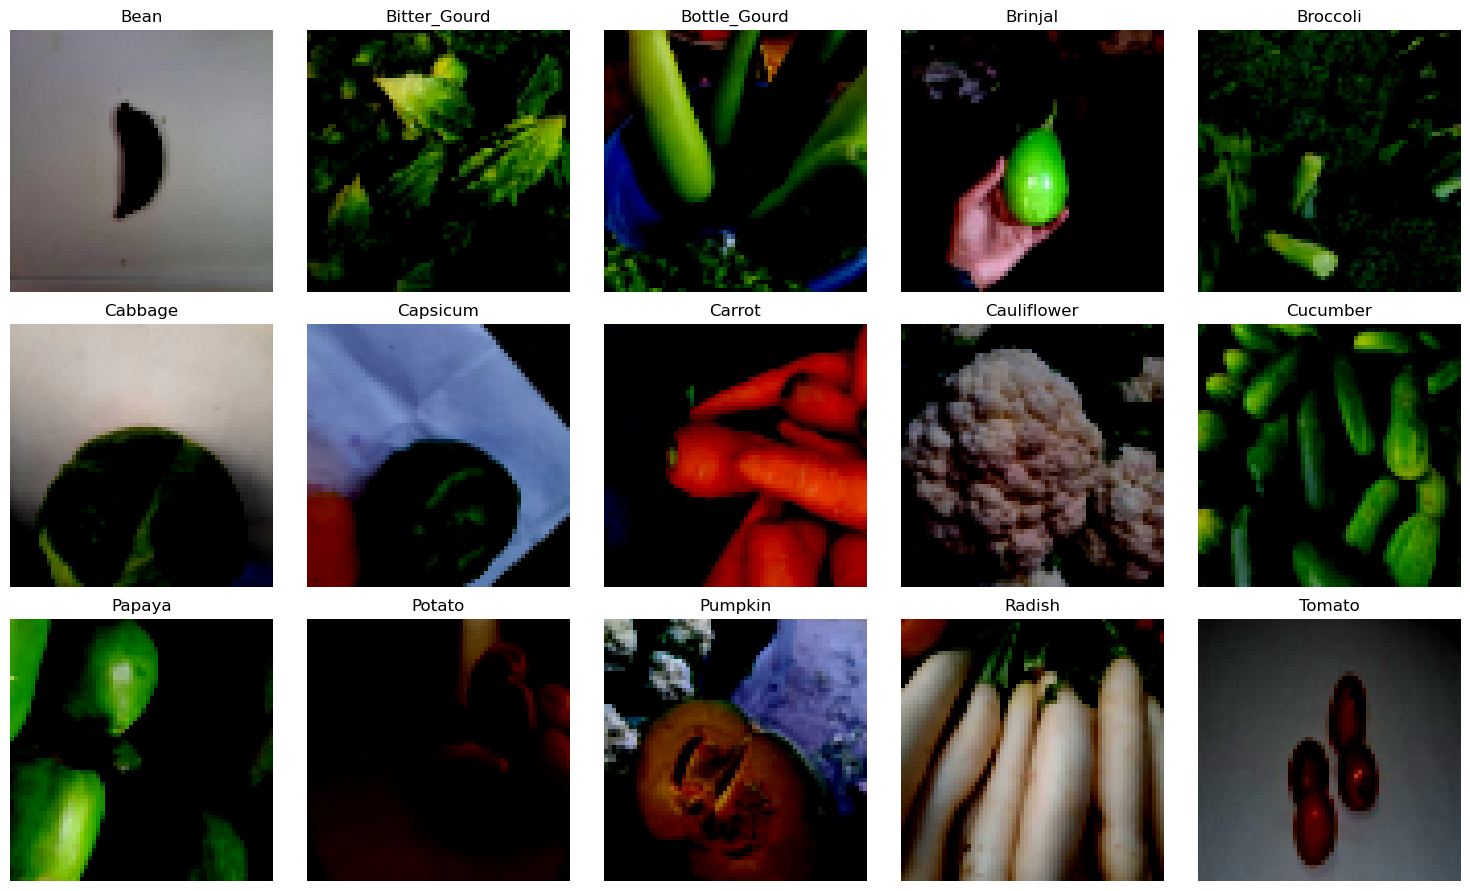

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_classes = len(trainset.classes)
r, c = 3, 5
plt.figure(figsize=(c*3, r*3))

for i in range(num_classes):
    for idx in range(len(trainset)):
        img, label = trainset[idx]
        if label == i:
            break
    img_np = np.transpose(img.numpy(), (1, 2, 0))
    plt.subplot(r, c, i+1)
    plt.imshow(img_np)
    plt.axis('off')
    plt.title(trainset.classes[i])

plt.tight_layout()
plt.show()

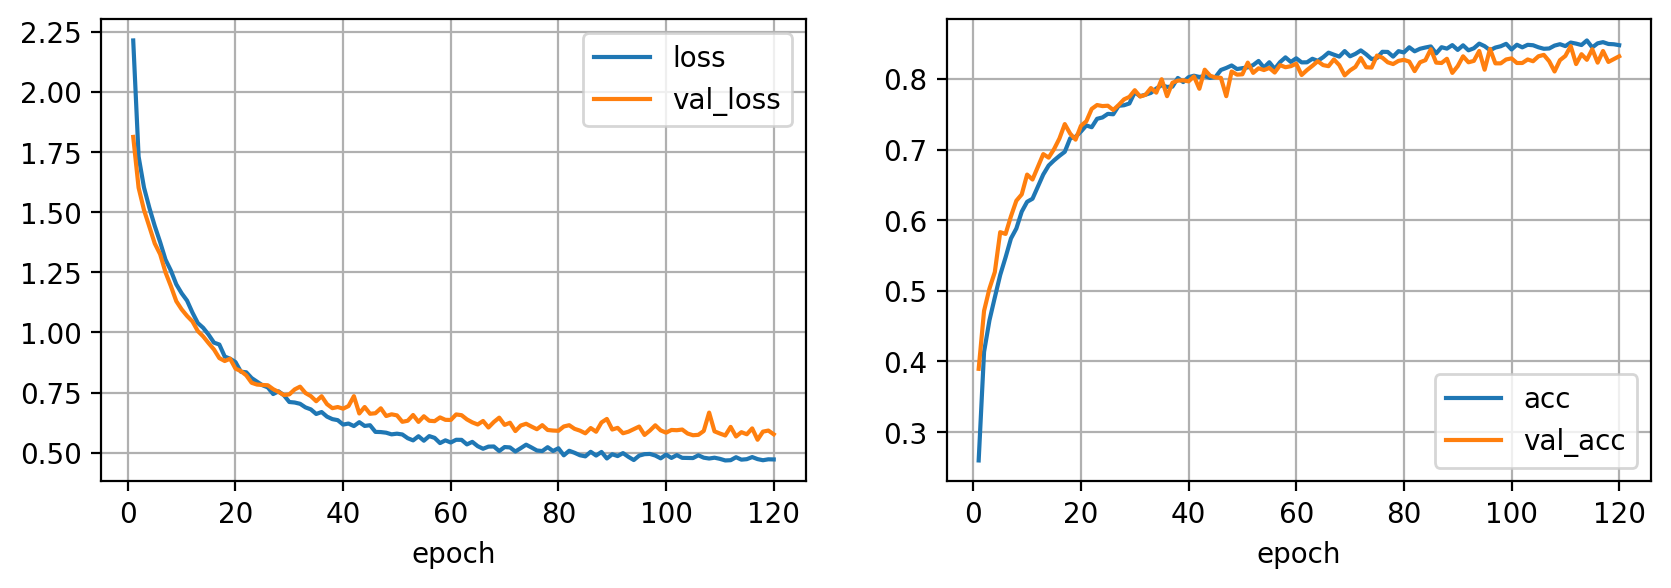

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_adam).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_adam).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

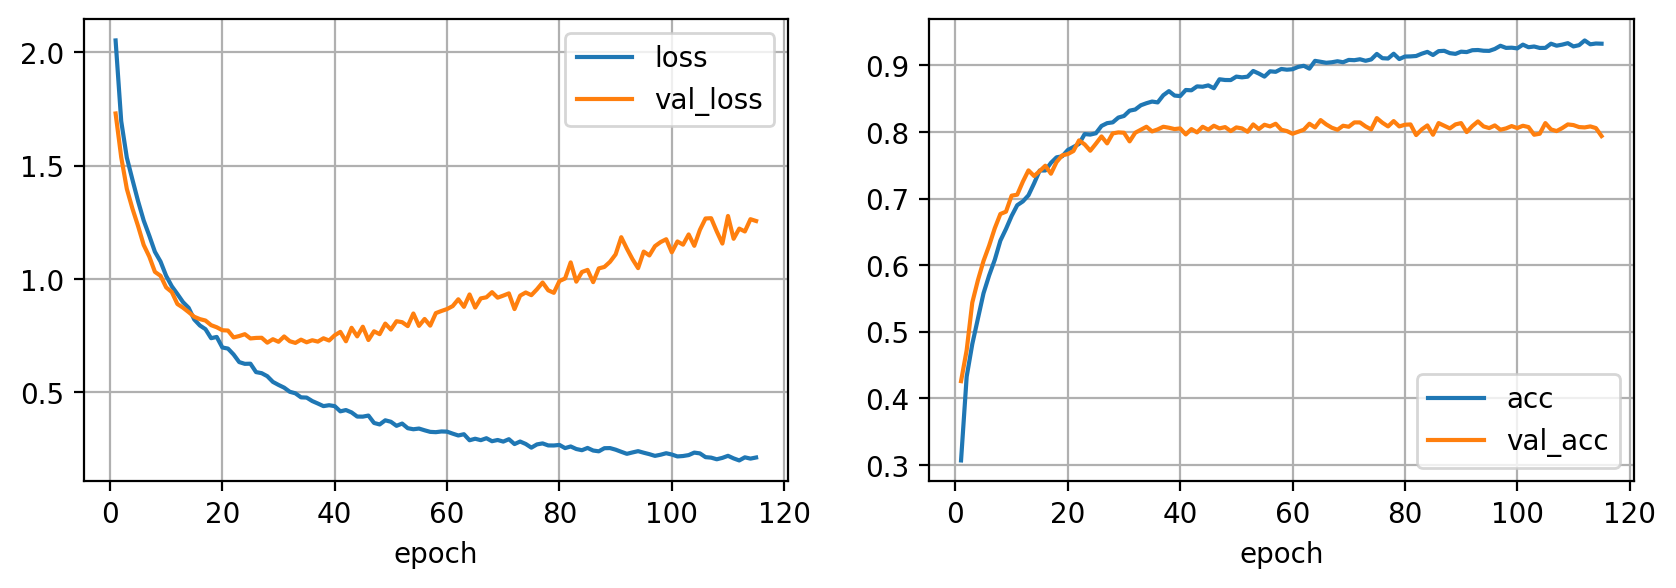

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_rms).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_rms).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

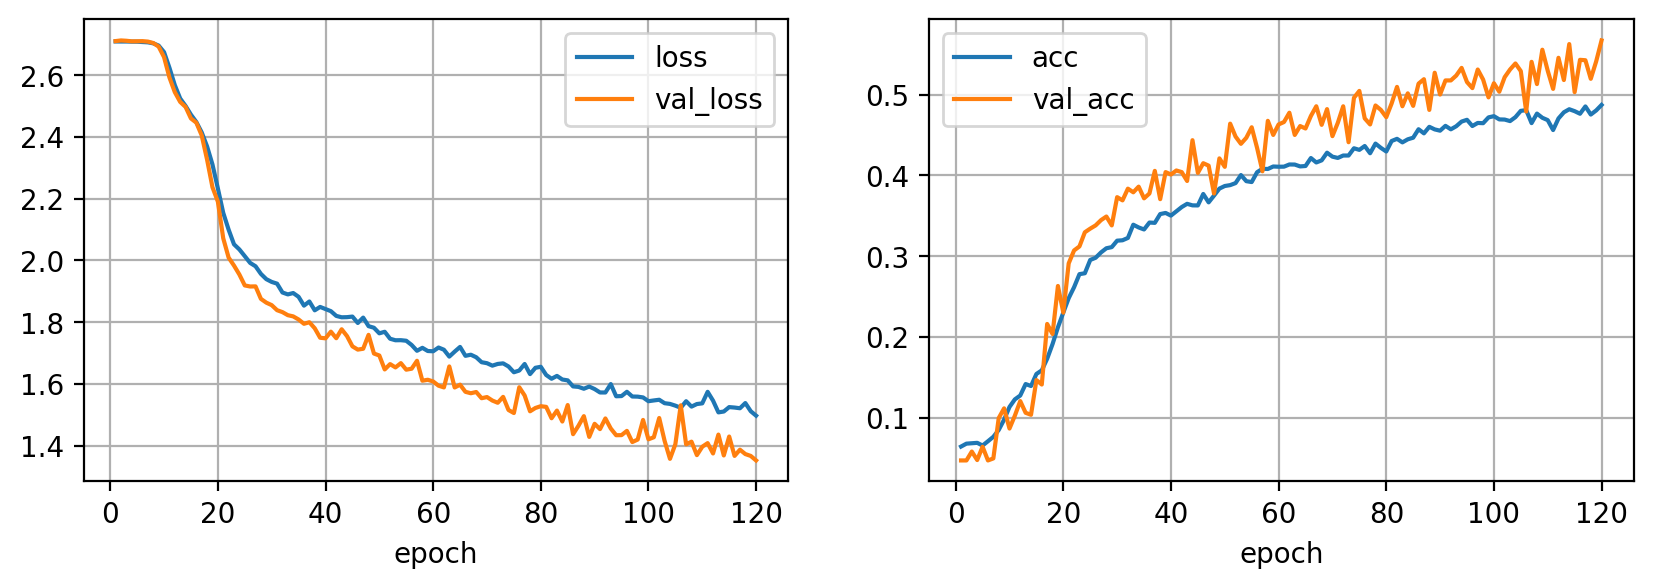

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_momentum).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_momentum).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

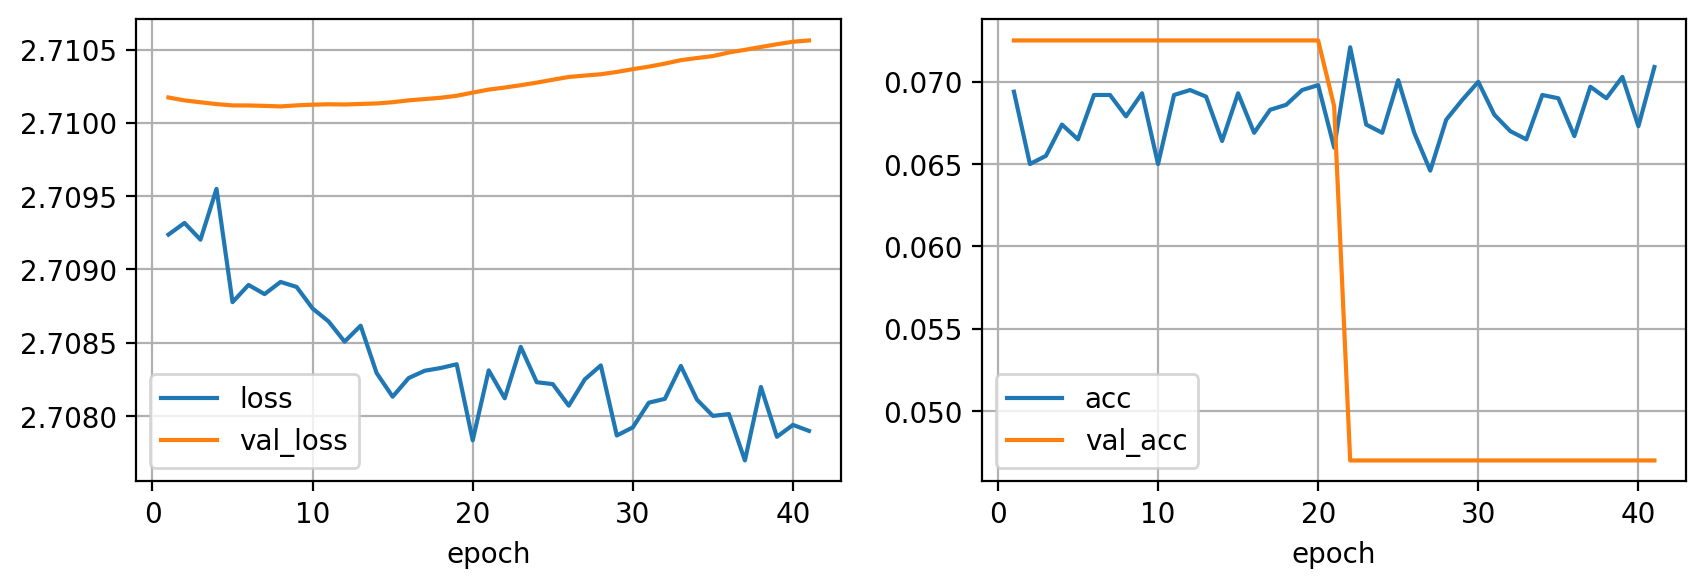

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_sgd).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_sgd).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

## *Learning Rate Scheduling*

In [ ]:
def fit(model, dataloader, optimizer, scheduler=None, epochs=100, log_each=10, weight_decay=0, early_stopping=0):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        if scheduler:
            scheduler.step()
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

In [ ]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 10, 0.1)

hist_step = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.06700 en epoch 1
Mejor modelo guardado con acc 0.08950 en epoch 7
Mejor modelo guardado con acc 0.14950 en epoch 8
Epoch 10/30 loss 2.59913 acc 0.12440 val_loss 2.56604 val_acc 0.11650 lr 0.01000
Epoch 20/30 loss 2.50547 acc 0.14147 val_loss 2.50305 val_acc 0.12100 lr 0.00100
Epoch 30/30 loss 2.49524 acc 0.14597 val_loss 2.49850 val_acc 0.12650 lr 0.00010


C:\Users\hp\AppData\Local\Temp\ipykernel_24164\1219440060.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


In [ ]:
model = build_model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0001, max_lr=0.01, step_size_up=5, step_size_down=25)

hist_cycle = fit(model, dataloader, optimizer, scheduler, epochs=30)

Mejor modelo guardado con acc 0.06700 en epoch 1
Mejor modelo guardado con acc 0.07250 en epoch 8
Epoch 10/30 loss 2.70749 acc 0.07388 val_loss 2.71079 val_acc 0.04700 lr 0.00842
Mejor modelo guardado con acc 0.08650 en epoch 20
Epoch 20/30 loss 2.69779 acc 0.10573 val_loss 2.70082 val_acc 0.08650 lr 0.00446
Mejor modelo guardado con acc 0.09950 en epoch 21
Epoch 30/30 loss 2.63905 acc 0.13139 val_loss 2.64370 val_acc 0.09450 lr 0.00050


C:\Users\hp\AppData\Local\Temp\ipykernel_24164\1219440060.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('ckpt.pt'))


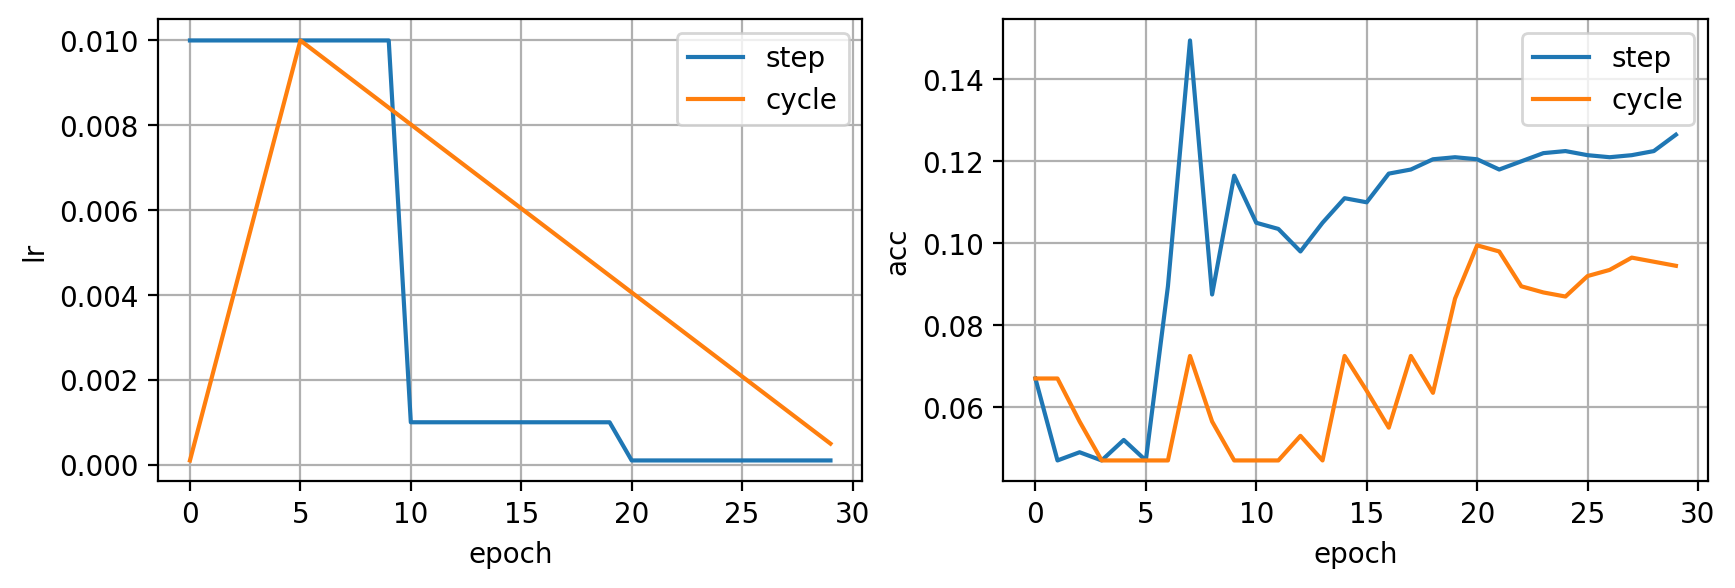

In [ ]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
ax.plot(hist_step['lr'], label="step")
ax.plot(hist_cycle['lr'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('lr')
ax = plt.subplot(122)
ax.plot(hist_step['val_acc'], label="step")
ax.plot(hist_cycle['val_acc'], label="cycle")
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()